# Advanced OOP Topics

In [1]:
import sys
from pathlib import Path

current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

sys.path.insert(0, str(project_root))

from shared import thinkpython, diagram, jupyturtle, download

sys.modules['thinkpython'] = thinkpython
sys.modules['diagram'] = diagram
sys.modules['jupyturtle'] = jupyturtle
sys.modules['download'] = download


### Copying

The `copy` module provides a function called `copy` that can duplicate any object.
We can import it like this.

In [23]:
from copy import copy

To see how it works, let's start with a new `Time` object that represents the start time of the movie.

In [24]:
start = make_time(9, 20, 0)

And make a copy.

In [25]:
end = copy(start)

Now `start` and `end` contain the same data.

In [26]:
print_time(start)
print_time(end)

09:20:00
09:20:00


But the `is` operator confirms that they are not the same object.

In [27]:
start is end

False

Let's see what the `==` operator does.

In [28]:
start == end

False

You might expect `==` to yield `True` because the objects contain the same data.
But for programmer-defined classes, the default behavior of the `==` operator is the same as the `is` operator -- it checks identity, not equivalence.

### Pure Functions

We can use `copy` to write pure functions that don't modify their parameters.
For example, here's a function that takes a `Time` object and a duration in hours, minutes and seconds.
It makes a copy of the original object, uses `increment_time` to modify the copy, and returns it.

In [29]:
def add_time(time, hours, minutes, seconds):
    total = copy(time)
    increment_time(total, hours, minutes, seconds)
    return total

Here's how we use it.

In [30]:
end = add_time(start, 1, 32, 0)
print_time(end)

10:52:00


The return value is a new object representing the end time of the movie.
And we can confirm that `start` is unchanged.

In [31]:
print_time(start)

09:20:00


`add_time` is a **pure function** because it does not modify any of the objects passed to it as arguments and its only effect is to return a value.

Anything that can be done with impure functions can also be done with pure functions.
In fact, some programming languages only allow pure functions.
Programs that use pure functions might be less error-prone, but impure functions are sometimes convenient and can be more efficient.

In general, I suggest you write pure functions whenever it is reasonable and resort to impure functions only if there is a compelling advantage.
This approach might be called a **functional programming style**.

### Prototype and Patch

In the previous example, `increment_time` and `add_time` seem to work, but if we try another example, we'll see that they are not quite correct.

Suppose you arrive at the theater and discover that the movie starts at `9:40`, not `9:20`.
Here's what happens when we compute the updated end time.

In [32]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

10:72:00


The result is not a valid time.
The problem is that `increment_time` does not deal with cases where the number of seconds or minutes adds up to more than `60`.

Here's an improved version that checks whether `second` exceeds or equals `60` -- if so, it increments `minute` -- then checks whether `minute` exceeds or equals `60` -- if so, it increments `hour`.

In [33]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    if time.second >= 60:
        time.second -= 60
        time.minute += 1

    if time.minute >= 60:
        time.minute -= 60
        time.hour += 1

Fixing `increment_time` also fixes `add_time`, which uses it.
So now the previous example works correctly.

In [34]:
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


But this function is still not correct, because the arguments might be bigger than `60`.
For example, suppose we are given the run time as `92` minutes, rather than `1` hours and `32` minutes.
We might call `add_time` like this.

In [35]:
end = add_time(start, 0, 92, 0)
print_time(end)

10:72:00


The result is not a valid time.
So let's try a different approach, using the `divmod` function.
We'll make a copy of `start` and modify it by incrementing the `minute` attribute.

In [36]:
end = copy(start)
end.minute = start.minute + 92
end.minute

132

Now `minute` is `132`, which is `2` hours and `12` minutes.
We can use `divmod` to divide by `60` and return the number of whole hours and the number of minutes left over.

In [37]:
carry, end.minute = divmod(end.minute, 60)
carry, end.minute

(2, 12)

Now `minute` is correct, and we can add the hours to `hour`.

In [38]:
end.hour += carry
print_time(end)

11:12:00


The result is a valid time.
We can do the same thing with `hour` and `second`, and encapsulate the whole process in a function.

In [39]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds
    
    carry, time.second = divmod(time.second, 60)
    carry, time.minute = divmod(time.minute + carry, 60)
    carry, time.hour = divmod(time.hour + carry, 24)

With this version of `increment_time`, `add_time` works correctly, even if the arguments exceed `60`.

In [40]:
end = add_time(start, 0, 90, 120)
print_time(end)

11:12:00


This section demonstrates a program development plan I call **prototype and patch**.
We started with a simple prototype that worked correctly for the first example.
Then we tested it with more difficult examples -- when we found an error, we modified the program to fix it, like putting a patch on tire with a puncture.

This approach can be effective, especially if you don't yet have a deep understanding of the problem.
But incremental corrections can generate code that is unnecessarily complicated -- since it deals with many special cases -- and unreliable -- since it is hard to know if you have
found all the errors.

## Representing cards

There are 52 playing cards in a standard deck -- each of them belongs to one of four suits and one of thirteen ranks. 
The suits are Spades, Hearts, Diamonds, and Clubs.
The ranks are Ace, 2, 3, 4, 5, 6, 7, 8, 9, 10, Jack, Queen, and King.
Depending on which game you are playing, an Ace can be higher than King or lower than 2.

If we want to define a new object to represent a playing card, it is obvious what the attributes should be: `rank` and `suit`.
It is less obvious what type the attributes should be.
One possibility is to use strings like `'Spade'` for suits and `'Queen'` for ranks.
A problem with this implementation is that it would not be easy to compare cards to see which had a higher rank or suit.

An alternative is to use integers to **encode** the ranks and suits.
In this context, "encode" means that we are going to define a mapping between numbers and suits, or between numbers and ranks.
This kind of encoding is not meant to be a secret (that would be "encryption").

For example, this table shows the suits and the corresponding integer codes:


| Suit | Code |
| --- | --- |
|  Spades     |   3  |
|  Hearts     |   2  |
|  Diamonds   |   1  |
|  Clubs      |   0  |

With this encoding, we can compare suits by comparing their codes.

To encode the ranks, we'll use the integer `2` to represent the rank `2`, `3` to represent `3`, and so on up to `10`.
The following table shows the codes for the face cards.

  
| Rank | Code |
| --- | --- |
|  Jack     |   11  |
|  Queen   |   12  |
|  King      |   13  |

And we can use either `1` or `14` to represent an Ace, depending on whether we want it to be considered lower or higher than the other ranks.

To represent these encodings, we will use two lists of strings, one with the names of the suits and the other with the names of the ranks.

Here's a definition for a class that represents a playing card, with these lists of strings as **class variables**, which are variables defined inside a class definition, but not inside a method.

In [6]:
class Card:
    """Represents a standard playing card."""

    suit_names = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
    rank_names = [None, 'Ace', '2', '3', '4', '5', '6', '7', 
                  '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']

The first element of `rank_names` is `None` because there is no card with rank zero. By including `None` as a place-keeper, we get a list with the nice property that the index `2` maps to the string `'2'`, and so on.

Class variables are associated with the class, rather than an instance of the class, so we can access them like this.

In [7]:
Card.suit_names

['Clubs', 'Diamonds', 'Hearts', 'Spades']

We can use `suit_names` to look up a suit and get the corresponding string.

In [8]:
Card.suit_names[0]

'Clubs'

And `rank_names` to look up a rank.

In [9]:
Card.rank_names[11]

'Jack'

## Card attributes

Here's an `__init__` method for the `Card` class -- it takes `suit` and `rank` as parameters and assigns them to attributes with the same names.

In [10]:
%%add_method_to Card

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

Now we can create a `Card` object like this.

In [11]:
queen = Card(1, 12)

We can use the new instance to access the attributes.

In [12]:
queen.suit, queen.rank

(1, 12)

It is also legal to use the instance to access the class variables.

In [13]:
queen.suit_names

['Clubs', 'Diamonds', 'Hearts', 'Spades']

But if you use the class, it is clearer that they are class variables, not attributes.

## Printing cards

Here's a `__str__` method for `Card` objects.

In [14]:
%%add_method_to Card

    def __str__(self):
        rank_name = Card.rank_names[self.rank]
        suit_name = Card.suit_names[self.suit]
        return f'{rank_name} of {suit_name}' 

When we print a `Card`, Python calls the `__str__` method to get a human-readable representation of the card.

In [15]:
print(queen)

Queen of Diamonds


The following is a diagram of the `Card` class object and the Card instance.
`Card` is a class object, so its type is `type`.
`queen` is an instance of `Card`, so its type is `Card`.
To save space, I didn't draw the contents of `suit_names` and `rank_names`.

In [16]:
from diagram import Binding, Value, Frame, Stack

bindings = [Binding(Value(name), draw_value=False)
            for name in ['suit_names', 'rank_names']]
    
frame1 = Frame(bindings, name='type', dy=-0.5, offsetx=0.77)
binding1 = Binding(Value('Card'), frame1)

bindings = [Binding(Value(name), Value(value))
            for name, value in zip(['suit', 'rank'], [1, 11])]
    
frame2 = Frame(bindings, name='Card', dy=-0.3, offsetx=0.33)
binding2 = Binding(Value('queen'), frame2)

stack = Stack([binding1, binding2], dy=-1.2)

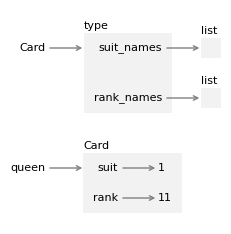

In [17]:
from diagram import diagram, Bbox, make_list, adjust

width, height, x, y = [2.11, 2.14, 0.35, 1.76]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)

value = make_list([])
bbox2 = value.draw(ax, x+1.66, y)

value = make_list([])
bbox3 = value.draw(ax, x+1.66, y-0.5)

bbox = Bbox.union([bbox, bbox2, bbox3])
#adjust(x, y, bbox)

Every `Card` instance has its own `suit` and `rank` attributes, but there is only one `Card` class object, and only one copy of the class variables `suit_names` and `rank_names`.

## Comparing cards

Suppose we create a second `Card` object with the same suit and rank.

In [18]:
queen2 = Card(1, 12)
print(queen2)

Queen of Diamonds


If we use the `==` operator to compare them, it checks whether `queen` and `queen2` refer to the same object.

In [19]:
queen == queen2

False

They don't, so it returns `False`.
We can change this behavior by defining the special method `__eq__`.

In [20]:
%%add_method_to Card

    def __eq__(self, other):
        return self.suit == other.suit and self.rank == other.rank

`__eq__` takes two `Card` objects as parameters and returns `True` if they have the same suit and rank, even if they are not the same object.
In other words, it checks whether they are equivalent, even if they are not identical.

When we use the `==` operator with `Card` objects, Python calls the `__eq__` method.

In [21]:
queen == queen2

True

As a second test, let's create a card with the same suit and a different rank.

In [22]:
six = Card(1, 6)
print(six)

6 of Diamonds


We can confirm that `queen` and `six` are not equivalent.

In [23]:
queen == six

False

If we use the `!=` operator, Python invokes a special method called `__ne__`, if it exists.
Otherwise it invokes`__eq__` and inverts the result -- so if `__eq__` returns `True`, the result of the `!=` operator is `False`.

In [24]:
queen != queen2

False

In [25]:
queen != six

True

Now suppose we want to compare two cards to see which is bigger.
If we use one of the relational operators, we get a `TypeError`.

In [26]:
%%expect TypeError

queen < queen2

TypeError: '<' not supported between instances of 'Card' and 'Card'

To change the behavior of the `<` operator, we can define a special method called `__lt__`, which is short for "less than".
For the sake of this example, let's assume that suit is more important than rank -- so all Spades outrank all Hearts, which outrank all Diamonds, and so on.
If two cards have the same suit, the one with the higher rank wins.

To implement this logic, we'll use the following method, which returns a tuple containing a card's suit and rank, in that order.

In [27]:
%%add_method_to Card

    def to_tuple(self):
        return (self.suit, self.rank)

We can use this method to write `__lt__`.

In [28]:
%%add_method_to Card

    def __lt__(self, other):
        return self.to_tuple() < other.to_tuple()

Tuple comparison compares the first elements from each tuple, which represent the suits.
If they are the same, it compares the second elements, which represent the ranks.

Now if we use the `<` operator, it invokes the `__lt__` method.

In [29]:
six < queen

True

If we use the `>` operator, it invokes a special method called `__gt__`, if it exists.
Otherwise it invokes `__lt__` with the arguments in the opposite order.

In [30]:
queen < queen2

False

In [31]:
queen > queen2

False

Finally, if we use the `<=` operator, it invokes a special method called `__le__`.

In [32]:
%%add_method_to Card

    def __le__(self, other):
        return self.to_tuple() <= other.to_tuple()

So we can check whether one card is less than or equal to another.

In [33]:
queen <= queen2

True

In [34]:
queen <= six

False

If we use the `>=` operator, it uses `__ge__` if it exists. Otherwise, it invokes `__le__` with the arguments in the opposite order.

In [35]:
queen >= six

True

As we have defined them, these methods are complete in the sense that we can compare any two `Card` objects, and consistent in the sense that results from different operators don't contradict each other.
With these two properties, we can say that `Card` objects are **totally ordered**.
And that means, as we'll see soon, that they can be sorted.

## Decks

Now that we have objects that represent cards, let's define objects that represent decks.
The following is a class definition for `Deck` with
an `__init__` method takes a list of `Card` objects as a parameter and assigns it to an attribute called `cards`.

In [36]:
class Deck:

    def __init__(self, cards):
        self.cards = cards

To create a list that contains the 52 cards in a standard deck, we'll use the following static method.

In [37]:
%%add_method_to Deck

    def make_cards():
        cards = []
        for suit in range(4):
            for rank in range(2, 15):
                card = Card(suit, rank)
                cards.append(card)
        return cards

In `make_cards`, the outer loop enumerates the suits from `0` to `3`.
The inner loop enumerates the ranks from `2` to `14` -- where `14` represents an Ace that outranks a King.
Each iteration creates a new `Card` with the current suit and rank, and appends it to `cards`.

Here's how we make a list of cards and a `Deck` object that contains it.

In [38]:
cards = Deck.make_cards()
deck = Deck(cards)
len(deck.cards)

52

It contains 52 cards, as intended.

## Printing the deck

Here is a `__str__` method for `Deck`.

In [39]:
%%add_method_to Deck

    def __str__(self):
        res = []
        for card in self.cards:
            res.append(str(card))
        return '\n'.join(res)

This method demonstrates an efficient way to accumulate a large string -- building a list of strings and then using the string method `join`. 

We'll test this method with a deck that only contains two cards.

In [40]:
small_deck = Deck([queen, six])

If we call `str`, it invokes `__str__`.

In [41]:
str(small_deck)

'Queen of Diamonds\n6 of Diamonds'

When Jupyter displays a string, it shows the "representational" form of the string, which represents a newline with the sequence `\n`.

However, if we print the result, Jupyter shows the "printable" form of the string, which prints the newline as whitespace.

In [42]:
print(small_deck)

Queen of Diamonds
6 of Diamonds


So the cards appear on separate lines.

## Add, remove, shuffle and sort

To deal cards, we would like a method that removes a card from the deck
and returns it. The list method `pop` provides a convenient way to do
that.

In [43]:
%%add_method_to Deck

    def take_card(self):
        return self.cards.pop()

Here's how we use it.

In [44]:
card = deck.take_card()
print(card)

Ace of Spades


We can confirm that there are `51` cards left in the deck.

In [45]:
len(deck.cards)

51

To add a card, we can use the list method `append`.

In [46]:
%%add_method_to Deck

    def put_card(self, card):
        self.cards.append(card)

As an example, we can put back the card we just popped.

In [47]:
deck.put_card(card)
len(deck.cards)

52

To shuffle the deck, we can use the `shuffle` function from the `random` module:

In [48]:
import random

In [49]:
# This cell initializes the random number generator so we
# always get the same results.

random.seed(3)

In [50]:
%%add_method_to Deck
            
    def shuffle(self):
        random.shuffle(self.cards)

If we shuffle the deck and print the first few cards, we can see that they are in no apparent order.

In [51]:
deck.shuffle()
for card in deck.cards[:4]:
    print(card)

2 of Diamonds
4 of Hearts
5 of Clubs
8 of Diamonds


To sort the cards, we can use the list method `sort`, which sorts the elements "in place" -- that is, it modifies the list rather than creating a new list.

In [52]:
%%add_method_to Deck
            
    def sort(self):
        self.cards.sort()

When we invoke `sort`, it uses the `__lt__` method to compare cards.

In [53]:
deck.sort()

If we print the first few cards, we can confirm that they are in increasing order.

In [54]:
for card in deck.cards[:4]:
    print(card)

2 of Clubs
3 of Clubs
4 of Clubs
5 of Clubs


In this example, `Deck.sort` doesn't do anything other than invoke `list.sort`.
Passing along responsibility like this is called **delegation**.

## Debugging

Inheritance is a useful feature.
Some programs that would be repetitive without inheritance can be written more concisely with it.
Also, inheritance can facilitate code reuse, since you can customize the behavior of a parent class without having to modify it.
In some cases, the inheritance structure reflects the natural structure of the problem, which makes the design easier to understand.

On the other hand, inheritance can make programs difficult to read.
When a method is invoked, it is sometimes not clear where to find its definition -- the relevant code may be spread across several modules.

Any time you are unsure about the flow of execution through your program, the simplest solution is to add print statements at the beginning of the relevant methods.
If `Deck.shuffle` prints a message that says something like `Running Deck.shuffle`, then as the program runs it traces the flow of execution.

As an alternative, you could use the following function, which takes an object and a method name (as a string) and returns the class that provides the definition of the method.

In [66]:
def find_defining_class(obj, method_name):
    """Find the class where the given method is defined."""
    for typ in type(obj).mro():
        if method_name in vars(typ):
            return typ
    return f'Method {method_name} not found.'

`find_defining_class` uses the `mro` method to get the list of class objects (types) that will be searched for methods.
"MRO" stands for "method resolution order", which is the sequence of classes Python searches to "resolve" a method name -- that is, to find the function object the name refers to.

As an example, let's instantiate a `BridgeHand` and then find the defining class of `shuffle`.

In [67]:
hand = BridgeHand('player 3')
find_defining_class(hand, 'shuffle')

__main__.Deck

## `@dataclass`

The `@dataclass` decorator (from `dataclasses`) automatically generates
`__init__`, `__repr__`, and `__eq__` for you based on class-level type
annotations. It drastically reduces boilerplate for simple data-holding classes.

```python
from dataclasses import dataclass

@dataclass
class Point:
    x: float
    y: float
```

This is equivalent to defining `__init__(self, x, y)`, `__repr__`, and
`__eq__` manually.


In [ ]:
from dataclasses import dataclass, field

@dataclass
class Student:
    name: str
    gpa: float
    courses: list = field(default_factory=list)  # mutable default

s1 = Student('Alice', 3.8)
s2 = Student('Alice', 3.8)

print(s1)            # Student(name='Alice', gpa=3.8, courses=[])
print(s1 == s2)      # True  — __eq__ compares field values
print(repr(s1))      # Student(name='Alice', gpa=3.8, courses=[])

s1.courses.append('CS101')
print(s1.courses)    # ['CS101']
print(s2.courses)    # [] — separate list (field(default_factory=list))


In [ ]:
### Exercise: Dataclass Design
#   Define a @dataclass named `Book` with fields:
#     title: str, author: str, year: int, pages: int = 0
#   Then:
#   1. Create two Book instances — one without specifying pages.
#   2. Print both — confirm __repr__ is auto-generated.
#   3. Check equality: two books with the same title/author/year/pages should be equal.
### Your code starts here.



### Your code ends here.


In [ ]:
### Solution
from dataclasses import dataclass

@dataclass
class Book:
    title: str
    author: str
    year: int
    pages: int = 0

b1 = Book('Think Python', 'Allen Downey', 2024)
b2 = Book('Think Python', 'Allen Downey', 2024, 350)
b3 = Book('Think Python', 'Allen Downey', 2024)

print(b1)           # Book(title='Think Python', author='Allen Downey', year=2024, pages=0)
print(b2)           # Book(title='Think Python', author='Allen Downey', year=2024, pages=350)
print(b1 == b3)     # True
print(b1 == b2)     # False  (pages differ)


## Summary

Optional but powerful OOP tools:

- **Copying**: shallow vs deep copy, `copy` module
- **Pure functions** vs in-place mutation with objects
- **Prototype-and-patch** development workflow
- **Card game**: a full worked OOP example (`Card`, `Deck`)
- **Debugging** OOP code
- **Dataclasses**: `@dataclass` for concise data containers
